# Week 10: Recommendation, Ranking, and Offline Evaluation

This notebook is the Week 10 deliverable for the anime recommendation project. The decision task is personalized anime ranking: given what a user has completed and liked, rank candidate anime that are plausible next discoveries.

The final product is not a single fixed list. It is a recommender with user controls and maturity-aware behavior: absolute beginners need safe entry points, amateurs need similarity and relation guidance, good users need a stronger personalized mix, and pro users need novelty and long-tail discovery.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent

ARTIFACT_DIR = BASE_DIR / 'artifacts' / 'recommendation'
PLOT_DIR = BASE_DIR / 'artifacts' / 'plots' / 'week10'
SCRIPT_PATH = BASE_DIR / 'src' / '08_run_week10_recommendation.py'

METRICS_PATH = ARTIFACT_DIR / 'week10_evaluation_metrics.csv'
LEVEL_METRICS_PATH = ARTIFACT_DIR / 'week10_metrics_by_user_level.csv'
SUMMARY_PATH = ARTIFACT_DIR / 'week10_recommendation_summary.json'
EXAMPLES_PATH = ARTIFACT_DIR / 'week10_recommendation_examples.csv'
ALIGNMENT_PATH = ARTIFACT_DIR / 'week10_data_alignment.csv'
USER_EVAL_PATH = ARTIFACT_DIR / 'week10_user_level_eval_sample.csv'
BEGINNER_PATH = ARTIFACT_DIR / 'week10_beginner_entrypoint_candidates.csv'

RUN_PIPELINE = False

if RUN_PIPELINE or not METRICS_PATH.exists() or not LEVEL_METRICS_PATH.exists():
    subprocess.run([sys.executable, str(SCRIPT_PATH)], cwd=BASE_DIR, check=True)

summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8'))
metrics = pd.read_csv(METRICS_PATH)
level_metrics = pd.read_csv(LEVEL_METRICS_PATH)
alignment = pd.read_csv(ALIGNMENT_PATH)
examples = pd.read_csv(EXAMPLES_PATH)
beginner_candidates = pd.read_csv(BEGINNER_PATH)
summary

{'task': 'personalized anime recommendation/ranking',
 'decision_supported': 'rank candidate anime for a user based on completed liked anime, while allowing product filters and maturity-aware recommendation modes',
 'baseline': 'popularity_baseline: globally common liked anime in training data',
 'stronger_system': 'latent_svd and hybrid_svd_popularity: personalized collaborative models that beat the popularity baseline',
 'product_safe_system': 'hybrid_svd_popularity: latent collaborative SVD score blended with popularity for safer sparse-profile recommendations',
 'user_levels': [{'level': 'Absolute Beginner',
   'min_known_entries': 0,
   'max_known_entries': 49,
   'primary_signal': 'guided onboarding, genre filters, popularity, score, short entry points',
   'risk': 'cold start: no reliable personal taste vector yet'},
  {'level': 'Amateur',
   'min_known_entries': 50,
   'max_known_entries': 149,
   'primary_signal': 'similar anime, relation navigation, popularity, high-rated cat

## Product Framing

The recommender has four levels of user maturity. This matters because a beginner recommendation and a pro recommendation should not optimize for the same thing.

- **Absolute Beginner**: the user may not know anime titles yet. The system should ask for genre/content preferences, show recognizable popular titles, avoid very long commitments, and respect explicit-content controls.
- **Amateur**: the user has enough watched titles to use similarity and relation edges, but not enough data to fully trust a latent profile. Recommendations mix similar anime, franchise continuation, and popular/high-rated anchors.
- **Good**: the user has enough history for collaborative filtering and cluster-level taste to matter. The system can add current/seasonal titles and controlled exploration outside the comfort zone.
- **Pro**: the user has already seen many obvious titles. The system must lean more on long-tail discovery, niche clusters, novelty, and graph-aware exploration.

The offline data contains ratings, not full chronological watch histories, so the level analysis uses known liked ratings as a proxy for experience.

In [2]:
pd.DataFrame(summary['user_levels'])

,level,min_known_entries,max_known_entries,primary_signal,risk
0,Absolute Beginner,0,49.0,"guided onboarding, genre filters, popularity, ...",cold start: no reliable personal taste vector yet
1,Amateur,50,149.0,"similar anime, relation navigation, popularity...",taste is still forming and may overfit to a fe...
2,Good,150,999.0,"collaborative filtering, relation continuation...",model should not only repeat the user's comfor...
3,Pro,1000,NaN,"long-tail discovery, novelty, niche clusters, ...",hardest group: most obvious catalog items are ...


## User Controls

The recommender should not behave like a black box. Users should be able to control broad filters before ranking: genre, demographic/content rating, explicit content, score floor, length, and release year. These controls are product constraints applied before or during ranking, not replacements for the ranking model.

In [3]:
pd.DataFrame([{'control': key, 'meaning': value} for key, value in summary['control_filters'].items()])

,control,meaning
0,genre_filter,include/exclude broad MAL genres
1,demographic_filter,"Josei, Kodomo, Seinen, Shoujo, Shounen, 18+"
2,content_rating_filter,"G, PG, PG-13, R, R+, Rx"
3,explicit_toggle,exclude or include Ecchi/Erotica/Hentai and ex...
4,score_floor,minimum MAL score when a user wants safer picks
5,episode_length_filter,episode count and total watchtime ranges
6,year_filter,release year or season recency range


## Data Alignment

The recommendation model uses the processed anime catalog as the item layer and `ratings_processed.csv` as the interaction layer. A positive interaction is a rating of 7 or higher, matching MAL's own `Good` label. The candidate pool is restricted to catalog items with enough positive ratings so that the collaborative model is not dominated by one-off noise.

In [4]:
alignment

,layer,rows,definition
0,catalog,14965,anime_dataset rows
1,positive_interactions,41928689,ratings >= 7 aligned to catalog
2,candidate_pool,9197,catalog anime with >= 20 positive interactions
3,model_users,109857,eligible users used for matrix factorization t...
4,evaluation_users,15000,users with one positive item held out


## Evaluation Protocol

This is a ranking evaluation. For each eligible user, one liked anime is deterministically held out. The model receives the remaining liked anime as the user's profile. It then ranks one held-out positive item against 100 sampled catalog negatives.

Because the ratings source has no timestamps, this is **not** a chronological next-watch test. The valid claim is narrower: when the user has liked a title, does the model rank that title near the top compared with plausible alternatives?

## Systems Compared

Three systems are compared:

- `popularity_baseline`: ranks globally common liked anime. This is a serious baseline because anime discovery is heavily popularity-driven.
- `latent_svd`: learns user and anime factors from the sparse positive user-anime matrix.
- `hybrid_svd_popularity`: blends normalized SVD score with popularity. This is the final offline model because it keeps personalization while avoiding overly obscure picks.

In [5]:
metrics

,method,evaluated_users,hit_rate_at_10,ndcg_at_10,mean_reciprocal_rank,median_rank,mean_rank,candidate_pool_per_user,like_threshold,min_user_positives,min_item_positives
0,latent_svd,15000,0.910200,0.716295,0.658316,1.0,5.693133,101,7,5,20
1,hybrid_svd_popularity,15000,0.909600,0.715660,0.658082,1.0,4.891133,101,7,5,20
2,popularity_baseline,15000,0.769867,0.501312,0.430417,4.0,7.838933,101,7,5,20


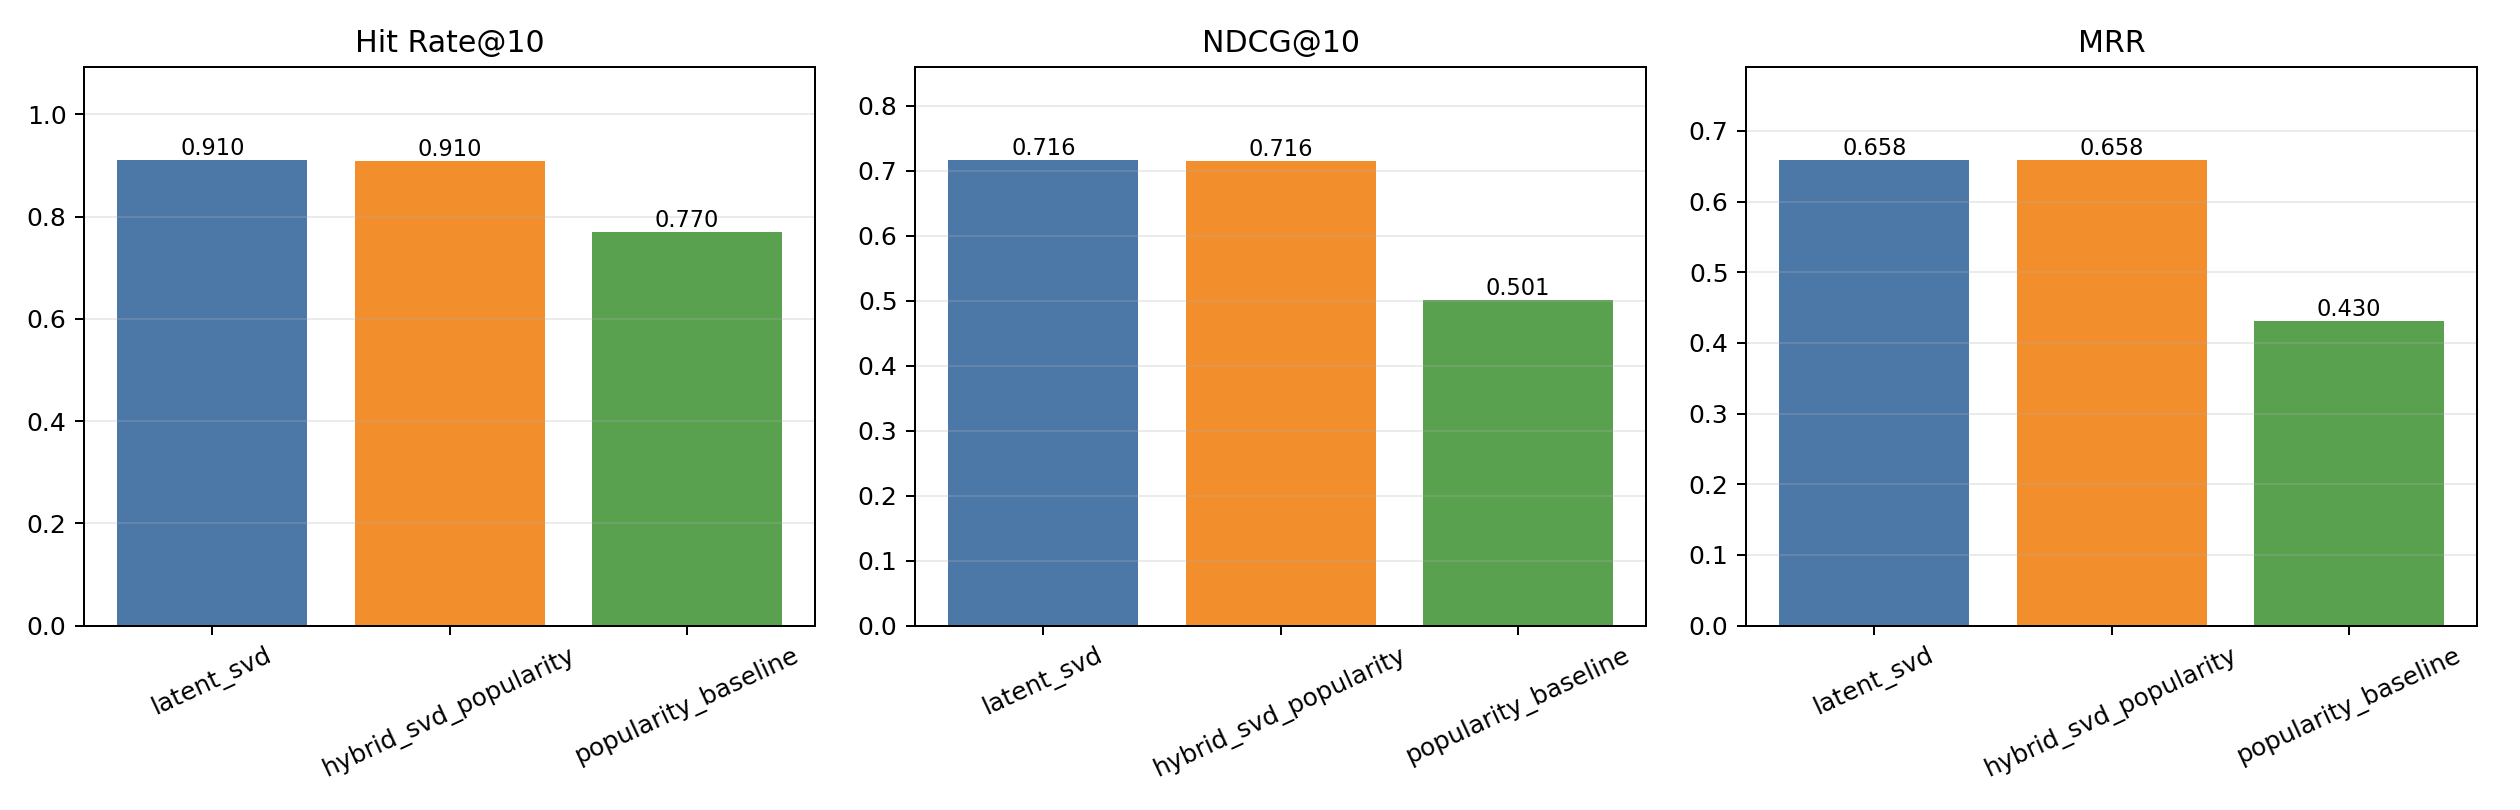

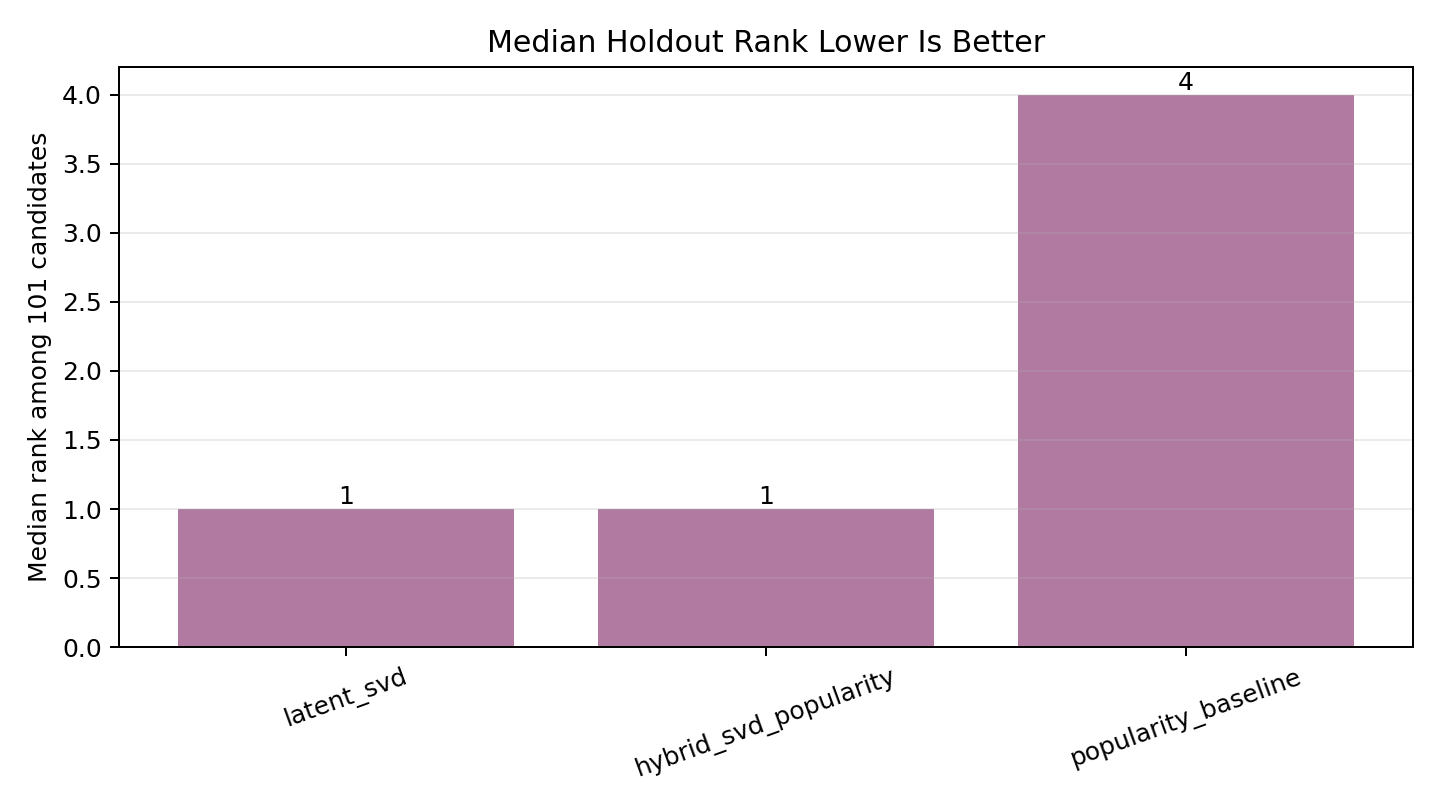

In [6]:
display(Image(filename=str(PLOT_DIR / 'week10_metric_comparison.png')))
display(Image(filename=str(PLOT_DIR / 'week10_median_rank.png')))

## Results by User Level

The level split is important for interpretation. Absolute beginners and amateurs benefit strongly from popularity and common taste neighborhoods. Good users are still well served by SVD, but the task gets harder as profiles become more diverse. Pro users are rare in this evaluation sample and are the hardest group because many obvious recommendations are likely already known.

In [7]:
level_metrics

,user_level,method,evaluated_users,median_profile_size,hit_rate_at_10,ndcg_at_10,mean_reciprocal_rank,median_rank,mean_rank
0,Absolute Beginner,hybrid_svd_popularity,4499,25.0,0.912647,0.744509,0.693796,1.0,5.693932
1,Absolute Beginner,latent_svd,4499,25.0,0.905535,0.741858,0.692099,1.0,7.260502
2,Absolute Beginner,popularity_baseline,4499,25.0,0.812180,0.551245,0.479973,3.0,6.672594
3,Amateur,hybrid_svd_popularity,5575,90.0,0.920359,0.728271,0.670647,1.0,4.445561
4,Amateur,latent_svd,5575,90.0,0.923767,0.730007,0.671323,1.0,5.119283
5,Amateur,popularity_baseline,5575,90.0,0.775785,0.508028,0.437039,3.0,7.643587
6,Good,hybrid_svd_popularity,4864,245.0,0.895765,0.676526,0.612773,2.0,4.621711
7,Good,latent_svd,4864,245.0,0.900082,0.678867,0.614256,2.0,4.880140
8,Good,popularity_baseline,4864,245.0,0.724918,0.448860,0.378553,5.0,9.072163
9,Pro,hybrid_svd_popularity,62,1153.5,0.806452,0.558321,0.491164,3.0,7.838710


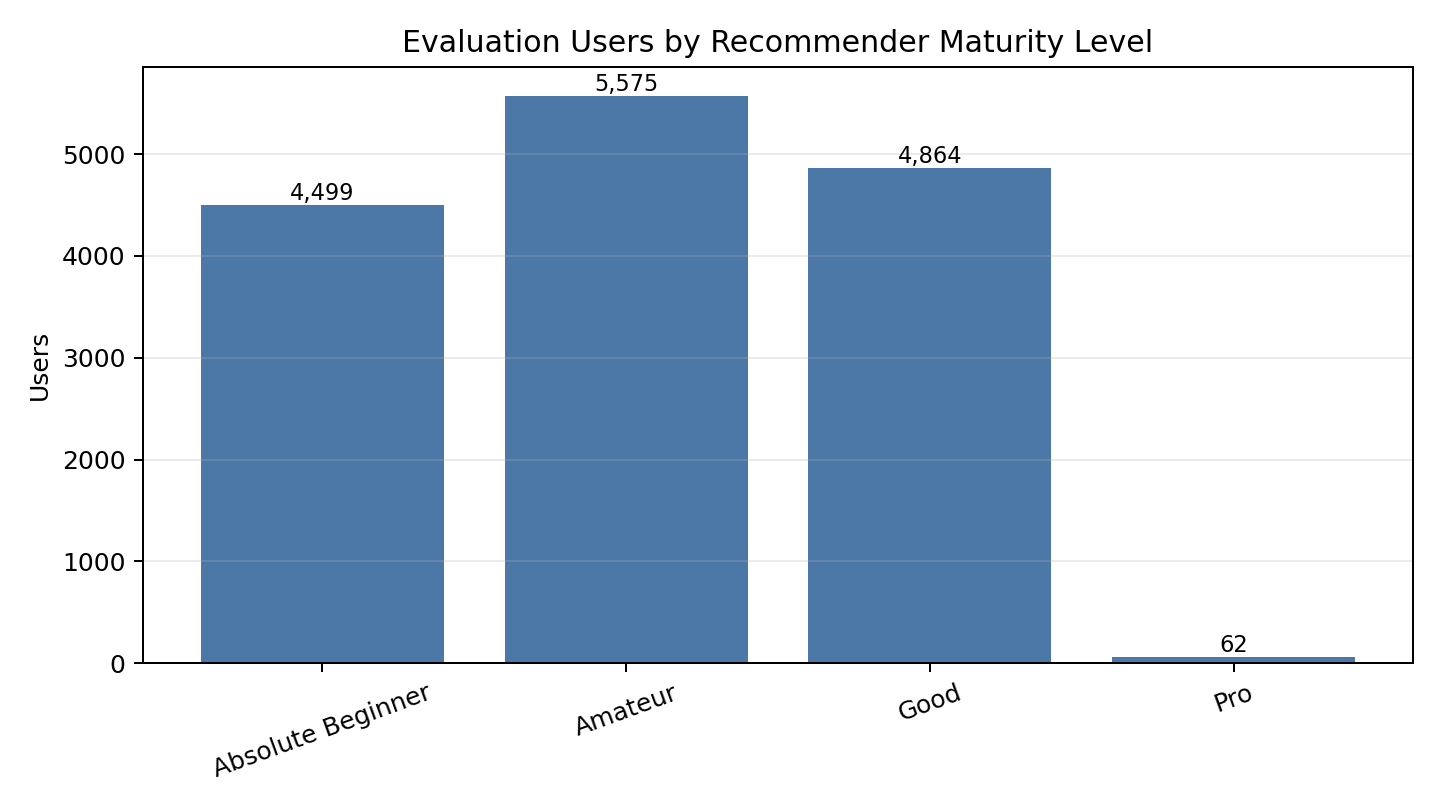

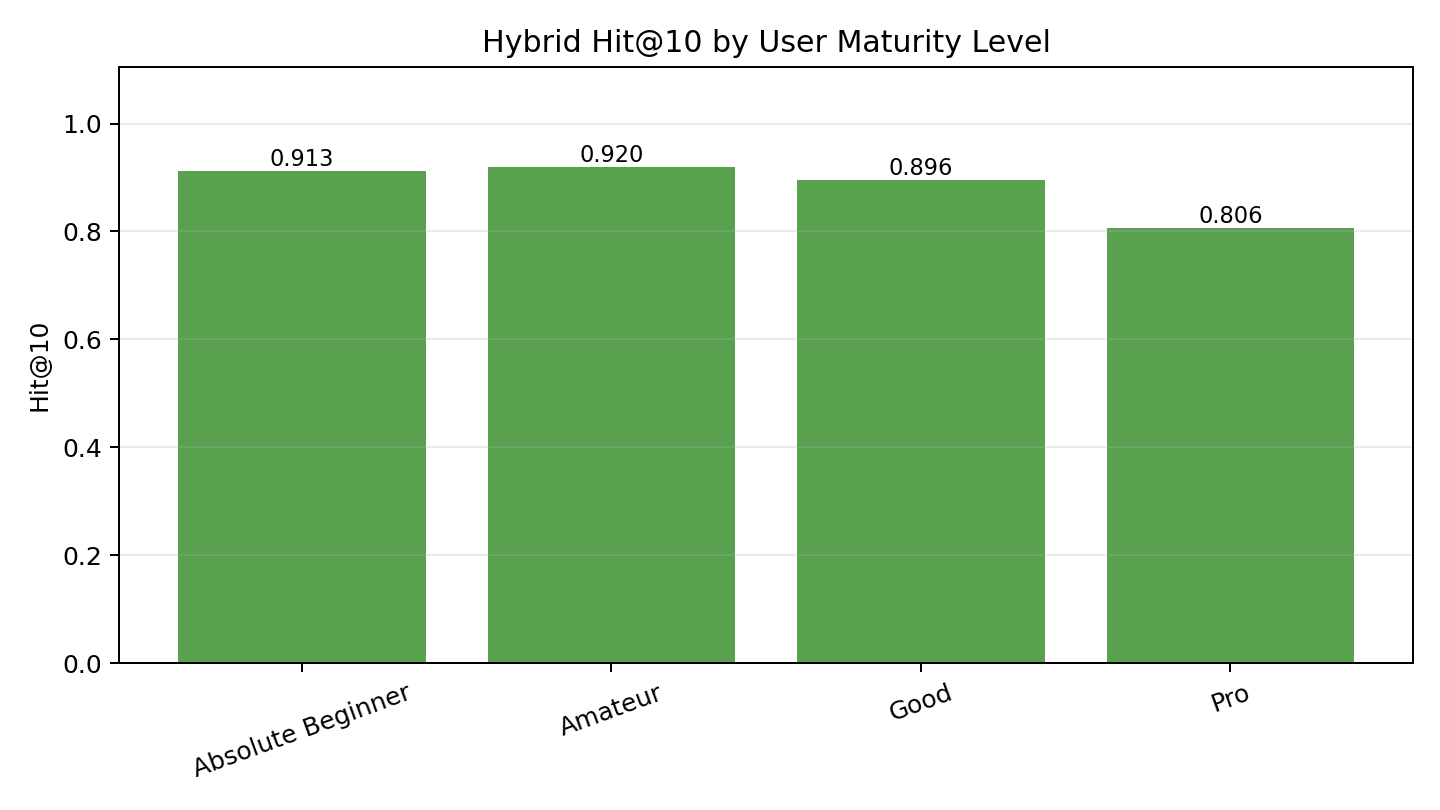

In [8]:
display(Image(filename=str(PLOT_DIR / 'week10_user_level_distribution.png')))
display(Image(filename=str(PLOT_DIR / 'week10_hit_at_10_by_user_level.png')))

## Beginner Entry-Point Candidates

For absolute beginners, the system should not immediately behave like a pure collaborative recommender. The generated beginner list filters out explicit entries and obvious continuation entries, then ranks high-score, high-engagement, shorter or medium-length entry points. This is an onboarding candidate pool, not the final personalized list.

In [9]:
beginner_candidates.head(25)

,mal_id,title,type,score,members,episodes,duration,total_watch_minutes,aired_year,genres,demographics,rating,beginner_entry_score,why_entry_level
0,52991,Sousou no Frieren,TV,9.26,1456504,28.0,24.0,672.0,2023.0,Adventure|Award Winning|Drama|Fantasy|Action|C...,Shounen,PG-13 - Teens 13 or older,0.780420,high-score popular short/medium-length series
1,9253,Steins;Gate,TV,9.07,2822509,24.0,24.0,576.0,2011.0,Drama|Sci-Fi|Suspense|Comedy|Romance,Seinen,PG-13 - Teens 13 or older,0.764050,high-score popular short/medium-length series
2,28851,Koe no Katachi,Movie,8.93,2627641,1.0,130.0,130.0,2016.0,Award Winning|Drama|Romance,Shounen,PG-13 - Teens 13 or older,0.748618,high-score popular movie; low commitment
3,32281,Kimi no Na wa.,Movie,8.82,3037822,1.0,106.0,106.0,2016.0,Award Winning|Drama|Sci-Fi|Comedy|Romance|Slic...,NaN,PG-13 - Teens 13 or older,0.740506,high-score popular movie; low commitment
4,5114,Fullmetal Alchemist: Brotherhood,TV,9.11,3696136,64.0,24.0,1536.0,2009.0,Action|Adventure|Drama|Fantasy|Sci-Fi|Comedy,Shounen,R - 17+ (violence & profanity),0.736388,high-score popular short/medium-length series
5,16498,Shingeki no Kyojin,TV,8.57,4377647,25.0,24.0,600.0,2013.0,Action|Award Winning|Drama|Suspense|Sci-Fi|Fan...,Shounen,R - 17+ (violence & profanity),0.715103,high-score popular short/medium-length series
6,37521,Vinland Saga,TV,8.78,1833638,24.0,24.0,576.0,2019.0,Action|Adventure|Drama,Seinen,R - 17+ (violence & profanity),0.700159,high-score popular short/medium-length series
7,33352,Violet Evergarden,TV,8.69,2005781,13.0,24.0,312.0,2018.0,Drama|Action|Sci-Fi|Romance|Slice of Life,Seinen,PG-13 - Teens 13 or older,0.687728,high-score popular short/medium-length series
8,1535,Death Note,TV,8.62,4314806,37.0,23.0,851.0,2006.0,Supernatural|Suspense|Fantasy|Romance|Mystery,Shounen,R - 17+ (violence & profanity),0.684968,high-score popular short/medium-length series
9,30276,One Punch Man,TV,8.47,3530194,12.0,24.0,288.0,2015.0,Action|Comedy|Gourmet|Sci-Fi|Sports,Seinen,R - 17+ (violence & profanity),0.684897,high-score popular short/medium-length series


## Example Recommendation Cases

The examples table stores held-out titles, the user's training titles, and the hybrid top-10 candidate list. These examples are useful for qualitative defense: the metric says how often the system works, but examples show whether the output feels like anime discovery rather than arbitrary IDs.

In [10]:
examples[['case_type', 'user_level', 'profile_size', 'holdout_title', 'popularity_rank', 'latent_svd_rank', 'hybrid_rank', 'train_titles', 'hybrid_top10_titles']].head(20)

,case_type,user_level,profile_size,holdout_title,popularity_rank,latent_svd_rank,hybrid_rank,train_titles,hybrid_top10_titles
0,hybrid_win,Absolute Beginner,23,One Piece Movie 01,12,4,4,Fullmetal Alchemist | Mononoke Hime | Shingets...,Chobits | Pokemon Movie 01: Mewtwo no Gyakushu...
1,both_hit,Absolute Beginner,49,Toradora!,1,2,2,Shinseiki Evangelion | Shinseiki Evangelion Mo...,Tokyo Ghoul √A | Toradora! | Youkoso Jitsuryok...
2,both_hit,Amateur,97,Sword Art Online Alternative: Gun Gale Online,6,2,2,Death Note | Special A | Soul Eater | Kuroshit...,Shingeki no Kyojin Season 2 | Sword Art Online...
3,both_hit,Good,324,Aldnoah.Zero,3,3,3,Trigun | Eyeshield 21 | Rurouni Kenshin: Meiji...,Danshi Koukousei no Nichijou | Strike the Bloo...
4,both_hit,Amateur,135,Kill la Kill,1,1,1,Shinseiki Evangelion | Shinseiki Evangelion Mo...,Kill la Kill | One Punch Man: Road to Hero | S...
5,hybrid_win,Amateur,63,Mizu no Kotoba,33,7,8,Howl no Ugoku Shiro | Perfect Blue | One Piece...,Made in Abyss Movie 3: Fukaki Tamashii no Reim...
6,both_hit,Amateur,129,Darker than Black: Ryuusei no Gemini,4,2,2,Cowboy Bebop | Hachimitsu to Clover | Aa! Mega...,School Rumble | Darker than Black: Ryuusei no ...
7,both_hit,Good,457,Ghost Hunt,7,7,7,Eyeshield 21 | Hungry Heart: Wild Striker | Na...,Vampire Knight Guilty | Darling in the FranXX ...
8,both_hit,Good,342,JoJo no Kimyou na Bouken (TV),2,1,1,Shingetsutan Tsukihime | Tenjou Tenge | Sen to...,JoJo no Kimyou na Bouken (TV) | Kami no Tou | ...
9,both_hit,Good,197,Sekirei: Pure Engagement,5,3,3,Cowboy Bebop | Naruto | Shinseiki Evangelion |...,K-On! | School Days | Sekirei: Pure Engagement...


## Interpretation and Limits

The hybrid model beats the popularity baseline, which supports using collaborative information instead of only recommending the most famous shows. Still, the evaluation is intentionally conservative in its claims. It does not prove chronological next-watch prediction, and the 100-negative sampled setting is easier than ranking the entire catalog.

The final recommender should combine four components: user controls, collaborative ranking, content/genre constraints, and relation-graph navigation. Relation edges are especially important for franchise handling: a main entry can be recommended first, and then sequels, side stories, summaries, and alternative settings can be offered as contextual next steps rather than mixed blindly into general discovery.

## Reproducibility

Run the Week 10 pipeline from the repository root with:

```bash
python src/08_run_week10_recommendation.py
```

Main outputs are saved in `artifacts/recommendation/` and `artifacts/plots/week10/`.